## Data Analysis Project
### Project:  Flight Delay Analysis
### Made By: Prabhjot Kaur
### Date: 14-09-2026

## Introduction 

Flight delays are a common issue in the aviation industry and can affect passengers, airlines, and airport operations. This project analyzes flight data to understand patterns in delays, cancellations, and diversions.

The analysis focuses on factors such as airlines, airports, months, years, and different delay reasons. Python libraries such as Pandas, NumPy, Matplotlib, and Seaborn are used for data processing, analysis, and visualization.

The main goal of this project is to identify important trends and factors related to flight delays and present the findings through clear and meaningful visualizations.

## Project Objectives

* Analyze flight delay patterns across different years and months.
* Identify airlines and airports with the highest number of delayed flights.
* Analyze the major reasons responsible for flight delays.
* Study flight cancellations and diversions.
* Compare total flights with delayed flights.
* Analyze average arrival delays across different months and airlines.
* Use data visualization to present important patterns and insights clearly.


## Libraries Used

### 1. Pandas

Used for data loading, cleaning, filtering, grouping, aggregation, and analysis.

### 2. NumPy

Used for numerical operations, calculations, and data manipulation.

### 3. Matplotlib

Used to create visualizations such as line charts, scatter plots, pie charts, and other graphs.

### 4. Seaborn

Used to create statistical visualizations such as bar plots and correlation heatmaps.


In [2]:
from datasets import load_dataset

ds = load_dataset("ml-project-group-3/kaggle-airline-delay")

df = ds["train"].to_pandas()

df.head()

c:\Users\Dell\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
0,2023,8,9E,Endeavor Air Inc.,ABE,"Allentown/Bethlehem/Easton, PA: Lehigh Valley ...",89.0,13.0,2.25,1.60,...,0.0,5.99,2.0,1.0,1375.0,71.0,761.0,118.0,0.0,425.0
1,2023,8,9E,Endeavor Air Inc.,ABY,"Albany, GA: Southwest Georgia Regional",62.0,10.0,1.97,0.04,...,0.0,7.42,0.0,1.0,799.0,218.0,1.0,62.0,0.0,518.0
2,2023,8,9E,Endeavor Air Inc.,AEX,"Alexandria, LA: Alexandria International",62.0,10.0,2.73,1.18,...,0.0,4.28,1.0,0.0,766.0,56.0,188.0,78.0,0.0,444.0
3,2023,8,9E,Endeavor Air Inc.,AGS,"Augusta, GA: Augusta Regional at Bush Field",66.0,12.0,3.69,2.27,...,0.0,1.57,1.0,1.0,1397.0,471.0,320.0,388.0,0.0,218.0
4,2023,8,9E,Endeavor Air Inc.,ALB,"Albany, NY: Albany International",92.0,22.0,7.76,0.00,...,0.0,11.28,2.0,0.0,1530.0,628.0,0.0,134.0,0.0,768.0


## Data Loading

The flight delay dataset was loaded from an online dataset repository using the Hugging Face `datasets` library. This approach allows the dataset to be accessed directly without manually downloading or storing a CSV file.

After loading the dataset, it was converted into a Pandas DataFrame for further data cleaning, analysis, and visualization.

The dataset contains information related to flight operations, including:

* Year and month
* Airline
* Airport
* Total arrival flights
* Delayed flights
* Arrival delays
* Cancellation and diversion information
* Different delay reasons such as carrier, weather, NAS, security, and late aircraft delays

The dataset was then prepared for Exploratory Data Analysis (EDA).


In [3]:
df.shape

(171666, 21)

## Dataset Overview

* **Original Rows:** 171,666
* **Cleaned Rows:** 171,223
* **Columns:** 21
* **Data Type:** Numerical and categorical
* **Main Information:** Flights, delays, cancellations, diversions, airlines, airports, and delay reasons.
* **Data Source:** Hugging Face Dataset

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 171666 entries, 0 to 171665
Data columns (total 21 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   year                 171666 non-null  int64  
 1   month                171666 non-null  int64  
 2   carrier              171666 non-null  str    
 3   carrier_name         171666 non-null  str    
 4   airport              171666 non-null  str    
 5   airport_name         171666 non-null  str    
 6   arr_flights          171426 non-null  float64
 7   arr_del15            171223 non-null  float64
 8   carrier_ct           171426 non-null  float64
 9   weather_ct           171426 non-null  float64
 10  nas_ct               171426 non-null  float64
 11  security_ct          171426 non-null  float64
 12  late_aircraft_ct     171426 non-null  float64
 13  arr_cancelled        171426 non-null  float64
 14  arr_diverted         171426 non-null  float64
 15  arr_delay            171426 

In [5]:
df.isnull().sum()

year                     0
month                    0
carrier                  0
carrier_name             0
airport                  0
airport_name             0
arr_flights            240
arr_del15              443
carrier_ct             240
weather_ct             240
nas_ct                 240
security_ct            240
late_aircraft_ct       240
arr_cancelled          240
arr_diverted           240
arr_delay              240
carrier_delay          240
weather_delay          240
nas_delay              240
security_delay         240
late_aircraft_delay    240
dtype: int64

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df[df["arr_flights"].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3880,2023,6,MQ,Envoy Air,CLL,"College Station/Bryan, TX: Easterwood Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,2023,6,MQ,Envoy Air,EUG,"Eugene, OR: Mahlon Sweet Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,2023,6,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3904,2023,6,MQ,Envoy Air,GRB,"Green Bay, WI: Green Bay Austin Straubel Inter...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,2023,6,MQ,Envoy Air,HPN,"White Plains, NY: Westchester County",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df[df["arr_del15"].isnull()].head()

,year,month,carrier,carrier_name,airport,airport_name,arr_flights,arr_del15,carrier_ct,weather_ct,...,security_ct,late_aircraft_ct,arr_cancelled,arr_diverted,arr_delay,carrier_delay,weather_delay,nas_delay,security_delay,late_aircraft_delay
3880,2023,6,MQ,Envoy Air,CLL,"College Station/Bryan, TX: Easterwood Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3894,2023,6,MQ,Envoy Air,EUG,"Eugene, OR: Mahlon Sweet Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3898,2023,6,MQ,Envoy Air,FSD,"Sioux Falls, SD: Joe Foss Field",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3904,2023,6,MQ,Envoy Air,GRB,"Green Bay, WI: Green Bay Austin Straubel Inter...",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3910,2023,6,MQ,Envoy Air,HPN,"White Plains, NY: Westchester County",NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
print("Years:", df["year"].unique())
print("Months:", df["month"].unique())
print("Airlines:", df["carrier_name"].nunique())
print("Airports:", df["airport_name"].nunique())

Years: [2023 2022 2021 2020 2019 2018 2017 2016 2015 2014 2013]
Months: [ 8  7  6  5  4  3  2  1 12 11 10  9]
Airlines: 23
Airports: 419


In [10]:
df["carrier_name"].value_counts()

carrier_name
SkyWest Airlines Inc.           25593
Delta Air Lines Inc.            16725
Envoy Air                       11886
American Airlines Inc.          11816
United Air Lines Inc.           11262
Southwest Airlines Co.          11109
ExpressJet Airlines Inc.        10147
Frontier Airlines Inc.           9105
Alaska Airlines Inc.             8367
Allegiant Air                    8280
Endeavor Air Inc.                7593
JetBlue Airways                  7552
Mesa Airlines Inc.               6378
PSA Airlines Inc.                6190
Republic Airline                 5727
Spirit Air Lines                 4698
Hawaiian Airlines Inc.           2157
US Airways Inc.                  1708
ExpressJet Airlines LLC          1436
Horizon Air                      1157
Virgin America                   1135
American Eagle Airlines Inc.     1045
AirTran Airways Corporation       600
Name: count, dtype: int64

In [11]:
df_clean = df.dropna().copy()

In [12]:
df_clean.shape

(171223, 21)

## Data Cleaning

The dataset was checked for missing values and duplicate records.

* Missing values were identified in several numerical columns.
* No duplicate records were found.
* Rows containing missing values were removed using `dropna()`.
* The dataset was reduced from 171,666 rows to 171,223 rows.
* The cleaned dataset contains no missing values and was used for further analysis.

In [13]:
df_clean.isnull().sum().sum()


np.int64(0)

In [14]:
airline_delays = df_clean.groupby("carrier_name")["arr_del15"].sum().sort_values(ascending=False)

airline_delays

carrier_name
Southwest Airlines Co.          2460563.0
American Airlines Inc.          1538261.0
Delta Air Lines Inc.            1198884.0
SkyWest Airlines Inc.           1167810.0
United Air Lines Inc.           1030741.0
JetBlue Airways                  647919.0
ExpressJet Airlines Inc.         540578.0
Envoy Air                        394625.0
Spirit Air Lines                 330708.0
Alaska Airlines Inc.             317730.0
Frontier Airlines Inc.           291403.0
Republic Airline                 270036.0
PSA Airlines Inc.                231648.0
Endeavor Air Inc.                200559.0
Mesa Airlines Inc.               170060.0
Allegiant Air                    149943.0
US Airways Inc.                  134516.0
Hawaiian Airlines Inc.            89794.0
Virgin America                    64605.0
American Eagle Airlines Inc.      61132.0
ExpressJet Airlines LLC           29672.0
Horizon Air                       28682.0
AirTran Airways Corporation       25226.0
Name: arr_del15, dtyp

### 1. Top 10 Airlines by Total Delayed Flights

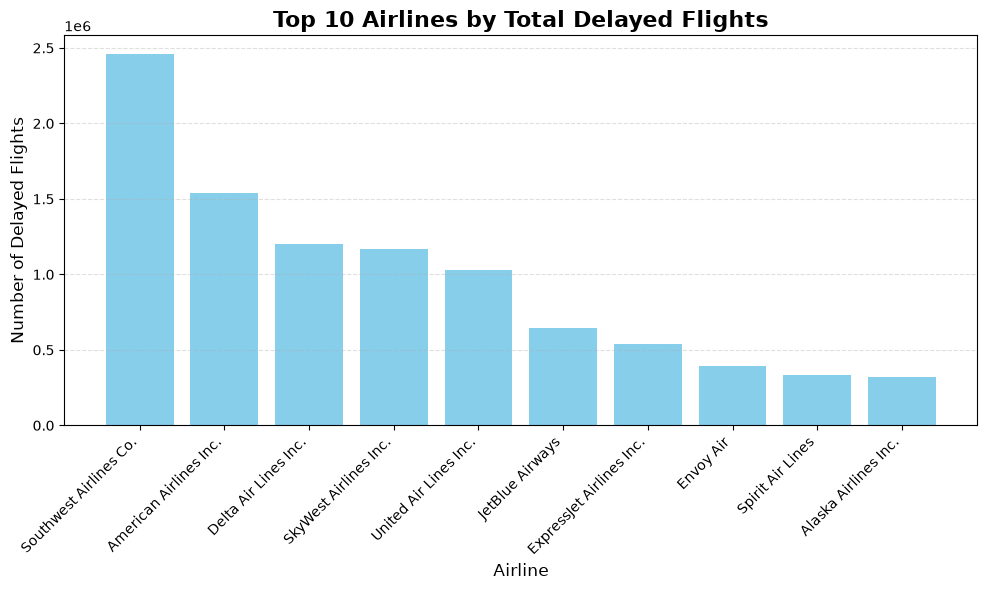

In [15]:
import matplotlib.pyplot as plt

top_airlines = airline_delays.head(10)

plt.figure(figsize=(10, 6))

plt.bar(
    top_airlines.index,
    top_airlines.values,
    color="skyblue"
)

plt.title(
    "Top 10 Airlines by Total Delayed Flights",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Airline", fontsize=12)
plt.ylabel("Number of Delayed Flights", fontsize=12)

plt.xticks(
    rotation=45,
    ha="right"
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 2. Top 10 Airlines by Delay Rate

In [16]:
airline_rate = (
    df_clean.groupby("carrier_name")
    .agg(
        total_flights=("arr_flights", "sum"),
        delayed_flights=("arr_del15", "sum")
    )
)

airline_rate["delay_rate"] = (
    airline_rate["delayed_flights"] /
    airline_rate["total_flights"]
) * 100

top_delay_rate = airline_rate.sort_values(
    "delay_rate",
    ascending=False
).head(10)

top_delay_rate

,total_flights,delayed_flights,delay_rate
carrier_name,,,
Frontier Airlines Inc.,1158917.0,291403.0,25.144424
JetBlue Airways,2609674.0,647919.0,24.827584
Allegiant Air,612350.0,149943.0,24.486486
American Eagle Airlines Inc.,279283.0,61132.0,21.888908
Spirit Air Lines,1525796.0,330708.0,21.674457
Virgin America,301907.0,64605.0,21.398974
ExpressJet Airlines Inc.,2637655.0,540578.0,20.494644
ExpressJet Airlines LLC,149209.0,29672.0,19.886200
Southwest Airlines Co.,12522217.0,2460563.0,19.649580


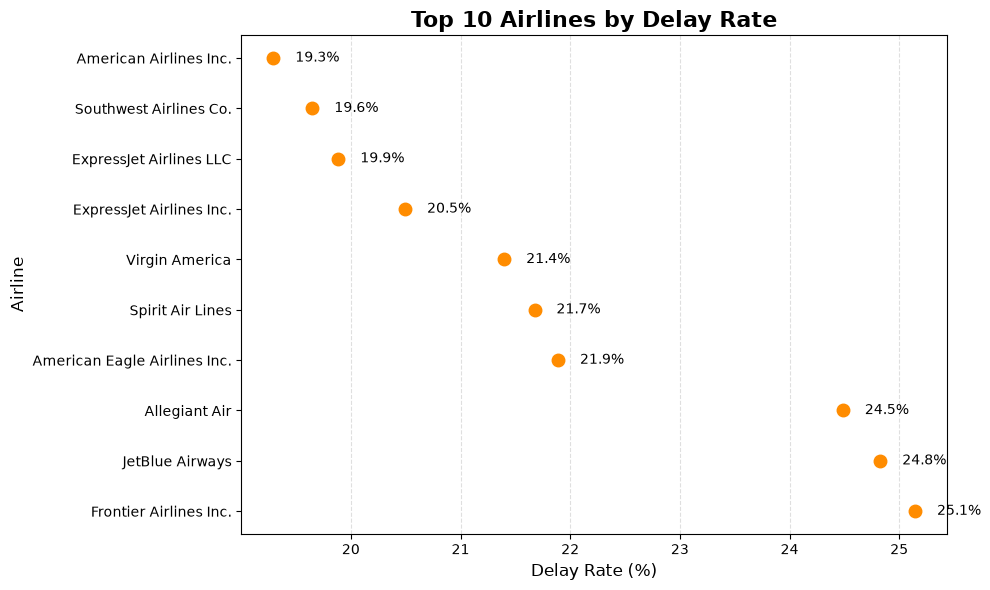

In [17]:
plt.figure(figsize=(10, 6))

plt.plot(
    top_delay_rate["delay_rate"],
    top_delay_rate.index,
    "o",
    markersize=9,
    color="darkorange"
)

for x, y in zip(
    top_delay_rate["delay_rate"],
    top_delay_rate.index
):
    plt.text(
        x + 0.2,
        y,
        f"{x:.1f}%",
        va="center",
        fontsize=10
    )

plt.title(
    "Top 10 Airlines by Delay Rate",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delay Rate (%)", fontsize=12)
plt.ylabel("Airline", fontsize=12)

plt.xticks(fontsize=10)
plt.yticks(fontsize=10)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 3. Monthly Flight Delays

In [18]:
month_delay = (
    df_clean.groupby("month")["arr_del15"]
    .sum()
)

month_delay

month
1      918519.0
2      855134.0
3      928208.0
4      848691.0
5      907663.0
6     1173371.0
7     1204979.0
8     1209494.0
9      703938.0
10     792054.0
11     751540.0
12    1081504.0
Name: arr_del15, dtype: float64

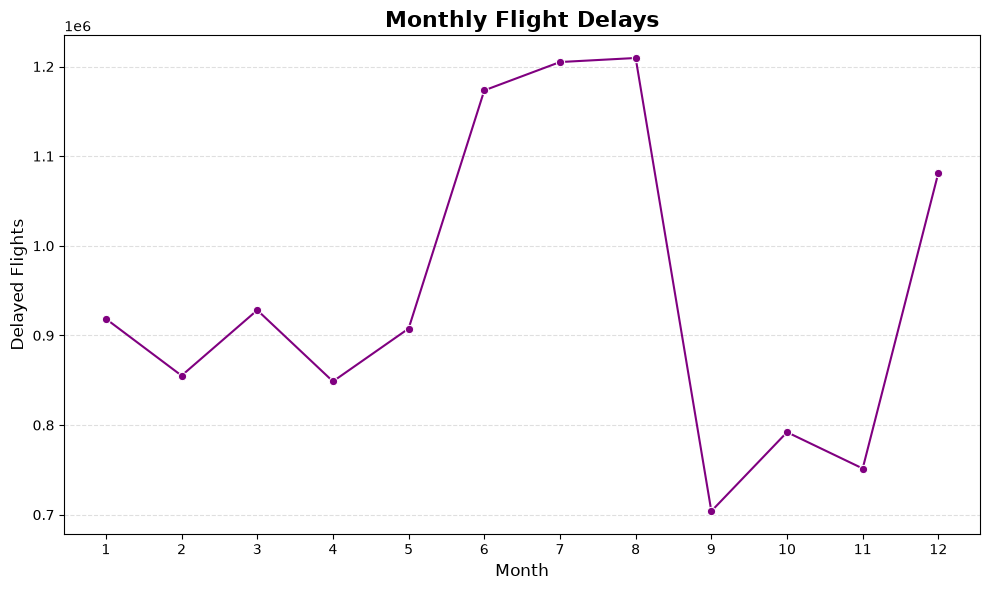

In [19]:
import seaborn as sns

plt.figure(figsize=(10, 6))

sns.lineplot(
    x=month_delay.index,
    y=month_delay.values,
    marker="o",
    color="purple"
)

plt.title(
    "Monthly Flight Delays",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Month", fontsize=12)
plt.ylabel("Delayed Flights", fontsize=12)

plt.xticks(range(1, 13))

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 4. Flight Delays by Reason

In [20]:
delay_reasons = df_clean[
    [
        "carrier_delay",
        "weather_delay",
        "nas_delay",
        "security_delay",
        "late_aircraft_delay"
    ]
].sum()

delay_reasons

carrier_delay          246370897.0
weather_delay           38153170.0
nas_delay              157823639.0
security_delay           1265591.0
late_aircraft_delay    283144335.0
dtype: float64

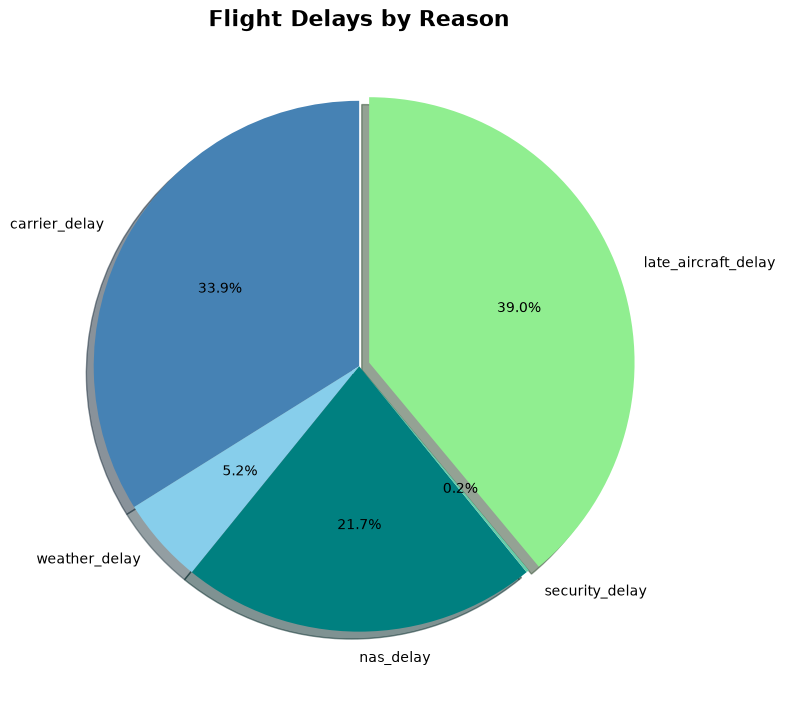

In [21]:
plt.figure(figsize=(8, 8))

explode = (0, 0, 0, 0, 0.04)

plt.pie(
    delay_reasons.values,
    labels=delay_reasons.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=explode,
    shadow=True,
    colors=[
        "steelblue",
        "skyblue",
        "teal",
        "mediumaquamarine",
        "lightgreen"
    ]
)

plt.title(
    "Flight Delays by Reason",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 5. Cancelled vs Non - Cancelled Flights

In [22]:
import pandas as pd 

cancelled = df_clean["arr_cancelled"].sum()
total_flights = df_clean["arr_flights"].sum()

non_cancelled = total_flights - cancelled

cancelled_data = pd.Series(
    [cancelled, non_cancelled],
    index=["Cancelled", "Not Cancelled"]
)

cancelled_data

Cancelled         1288913.0
Not Cancelled    60855863.0
dtype: float64

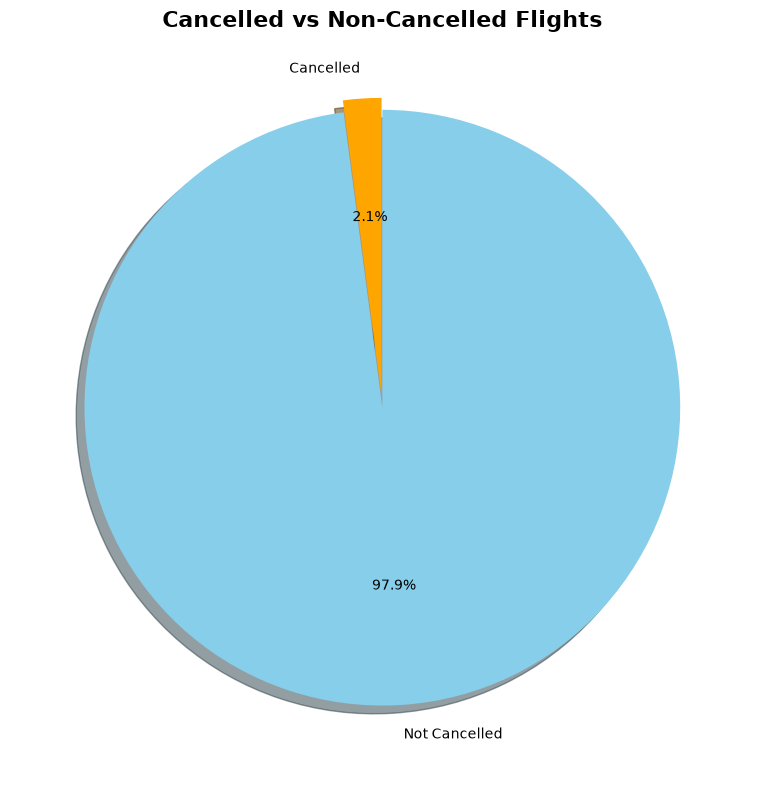

In [23]:
plt.figure(figsize=(8, 8))

plt.pie(
    cancelled_data.values,
    labels=cancelled_data.index,
    autopct="%1.1f%%",
    startangle=90,
    explode=(0.04, 0),
    shadow=True,
    colors=["orange", "skyblue"]
)

plt.title(
    "Cancelled vs Non-Cancelled Flights",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 6. Top 10 Airports by Delayed Flights

In [24]:
airport_delay = (
    df_clean.groupby("airport_name")["arr_del15"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

airport_delay

airport_name
Chicago, IL: Chicago O'Hare International                 535940.0
Atlanta, GA: Hartsfield-Jackson Atlanta International     508434.0
Dallas/Fort Worth, TX: Dallas/Fort Worth International    481259.0
Denver, CO: Denver International                          433104.0
Los Angeles, CA: Los Angeles International                397496.0
San Francisco, CA: San Francisco International            345825.0
Newark, NJ: Newark Liberty International                  288816.0
Phoenix, AZ: Phoenix Sky Harbor International             274354.0
New York, NY: LaGuardia                                   274099.0
Orlando, FL: Orlando International                        271800.0
Name: arr_del15, dtype: float64

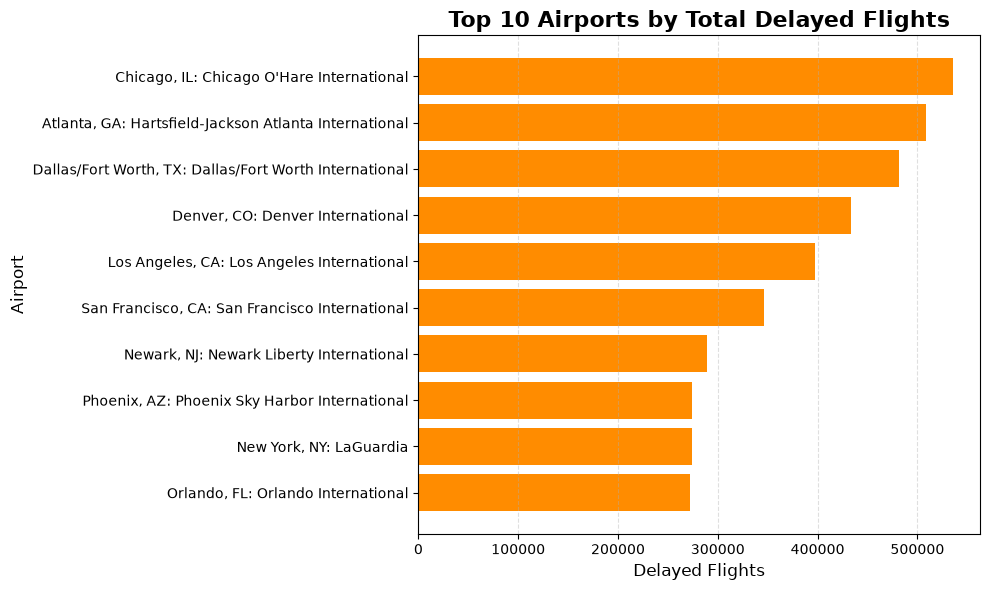

In [25]:
plt.figure(figsize=(10, 6))

plt.barh(
    airport_delay.index[::-1],
    airport_delay.values[::-1],
    color="darkorange"
)

plt.title(
    "Top 10 Airports by Total Delayed Flights",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Delayed Flights", fontsize=12)
plt.ylabel("Airport", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 7. Top 10 Airlines by Cancelled Flights

In [26]:
airline_cancellations = (
    df_clean.groupby("carrier_name")["arr_cancelled"]
    .sum()
    .sort_values(ascending=False)
)

airline_cancellations

carrier_name
Southwest Airlines Co.          275976.0
American Airlines Inc.          167452.0
SkyWest Airlines Inc.           138734.0
United Air Lines Inc.            86780.0
ExpressJet Airlines Inc.         85834.0
Delta Air Lines Inc.             85376.0
Envoy Air                        74187.0
JetBlue Airways                  59486.0
Republic Airline                 55324.0
PSA Airlines Inc.                43833.0
Spirit Air Lines                 34027.0
Endeavor Air Inc.                31506.0
Mesa Airlines Inc.               30339.0
Alaska Airlines Inc.             25876.0
Allegiant Air                    23307.0
Frontier Airlines Inc.           22037.0
American Eagle Airlines Inc.     15074.0
US Airways Inc.                  12167.0
ExpressJet Airlines LLC           8173.0
Hawaiian Airlines Inc.            4849.0
Horizon Air                       3608.0
Virgin America                    3156.0
AirTran Airways Corporation       1812.0
Name: arr_cancelled, dtype: float64

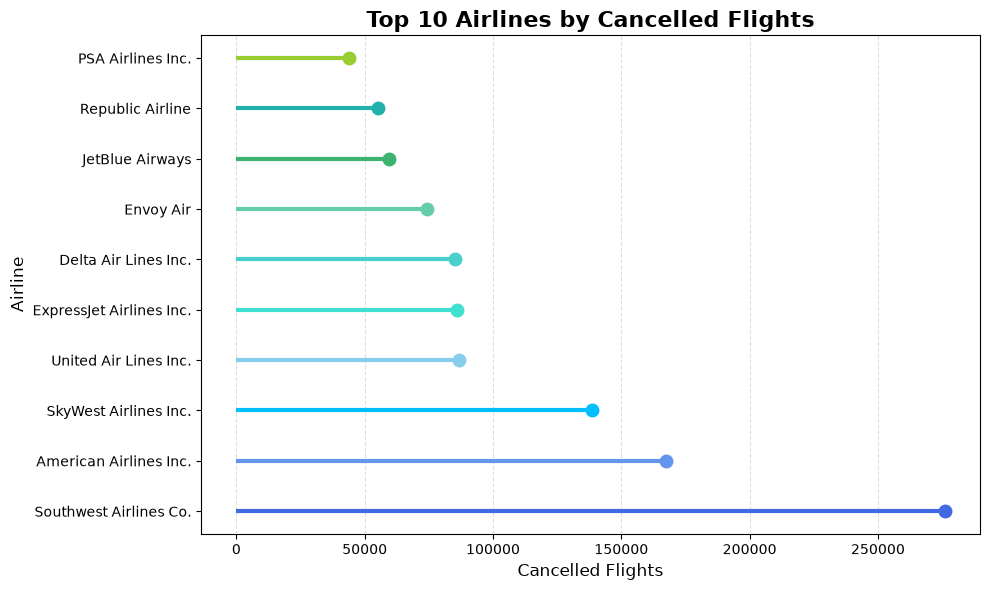

In [27]:
import numpy as np

top_10_cancelled = airline_cancellations.head(10)

y = np.arange(len(top_10_cancelled))

colors = [
    "royalblue",
    "cornflowerblue",
    "deepskyblue",
    "skyblue",
    "turquoise",
    "mediumturquoise",
    "mediumaquamarine",
    "mediumseagreen",
    "lightseagreen",
    "yellowgreen"
]

plt.figure(figsize=(10, 6))

for i, (value, color) in enumerate(
    zip(top_10_cancelled.values, colors)
):
    plt.hlines(
        i,
        0,
        value,
        color=color,
        linewidth=3
    )

    plt.plot(
        value,
        i,
        "o",
        color=color,
        markersize=9
    )

plt.yticks(y, top_10_cancelled.index)

plt.title(
    "Top 10 Airlines by Cancelled Flights",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Cancelled Flights", fontsize=12)
plt.ylabel("Airline", fontsize=12)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 8. Year wise Flight Delays

In [28]:
year_delays = df_clean.groupby("year")["arr_del15"].sum()

year_delays

year
2013     493432.0
2014    1240528.0
2015    1063439.0
2016     964239.0
2017    1029474.0
2018    1352165.0
2019    1389253.0
2020     431921.0
2021    1010332.0
2022    1376798.0
2023    1023514.0
Name: arr_del15, dtype: float64

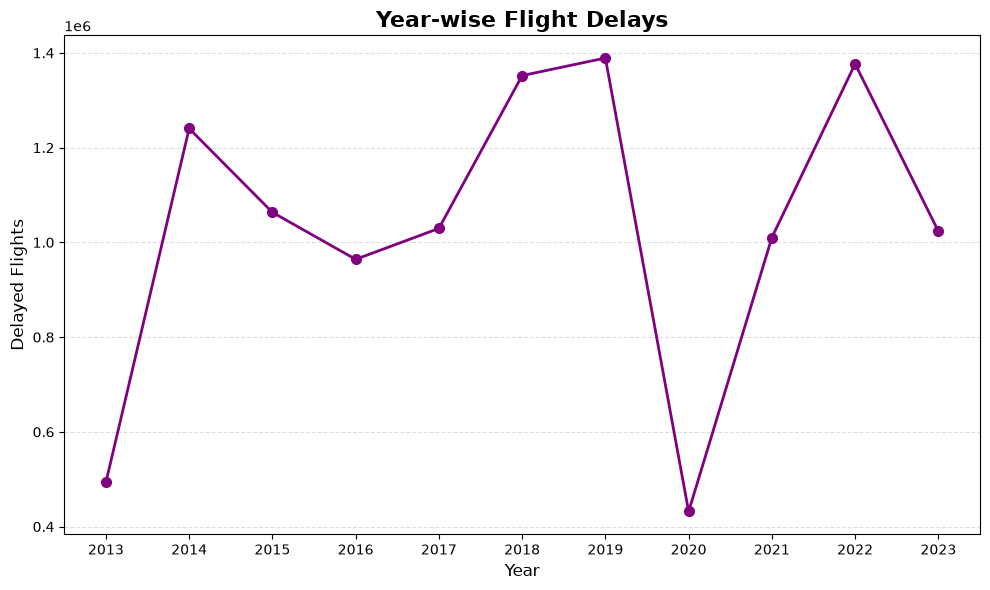

In [29]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_delays.index,
    year_delays.values,
    marker="o",
    linewidth=2,
    markersize=7,
    color="purple"
)

plt.title(
    "Year-wise Flight Delays",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Delayed Flights", fontsize=12)

plt.xticks(year_delays.index)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

In [30]:
year_delays.idxmax(), year_delays.max()

(np.int64(2019), np.float64(1389253.0))

### 9. Weather Delay vs Total Arrival Delay

In [31]:
weather_analysis = df_clean.groupby("year")[
    ["weather_delay", "arr_delay"]
].sum()

weather_analysis

,weather_delay,arr_delay
year,,
2013,941019.0,26106070.0
2014,2988669.0,70316961.0
2015,3100233.0,62651867.0
2016,2606083.0,59850360.0
2017,2799759.0,65816682.0
2018,4914804.0,87498074.0
2019,5282501.0,95889721.0
2020,1894289.0,26909950.0
2021,4580003.0,66613311.0


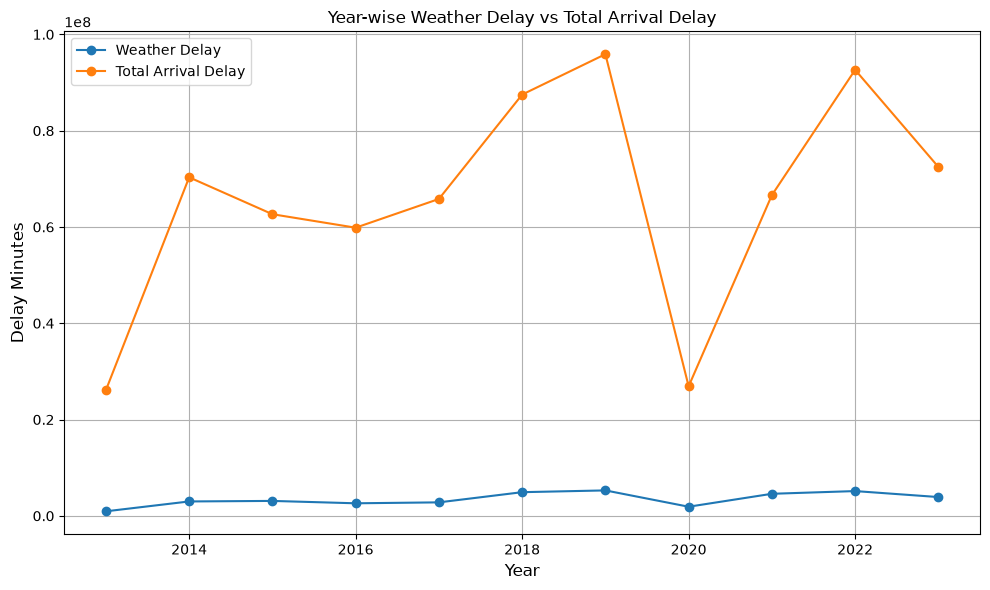

In [32]:
plt.figure(figsize=(10, 6))

plt.plot(
    weather_analysis.index,
    weather_analysis["weather_delay"],
    marker="o",
    label="Weather Delay"
)

plt.plot(
    weather_analysis.index,
    weather_analysis["arr_delay"],
    marker="o",
    label="Total Arrival Delay"
)

plt.title("Year-wise Weather Delay vs Total Arrival Delay")
plt.xlabel("Year", fontsize=12)
plt.ylabel("Delay Minutes", fontsize=12)

plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### 10. Flight Delay Correlation

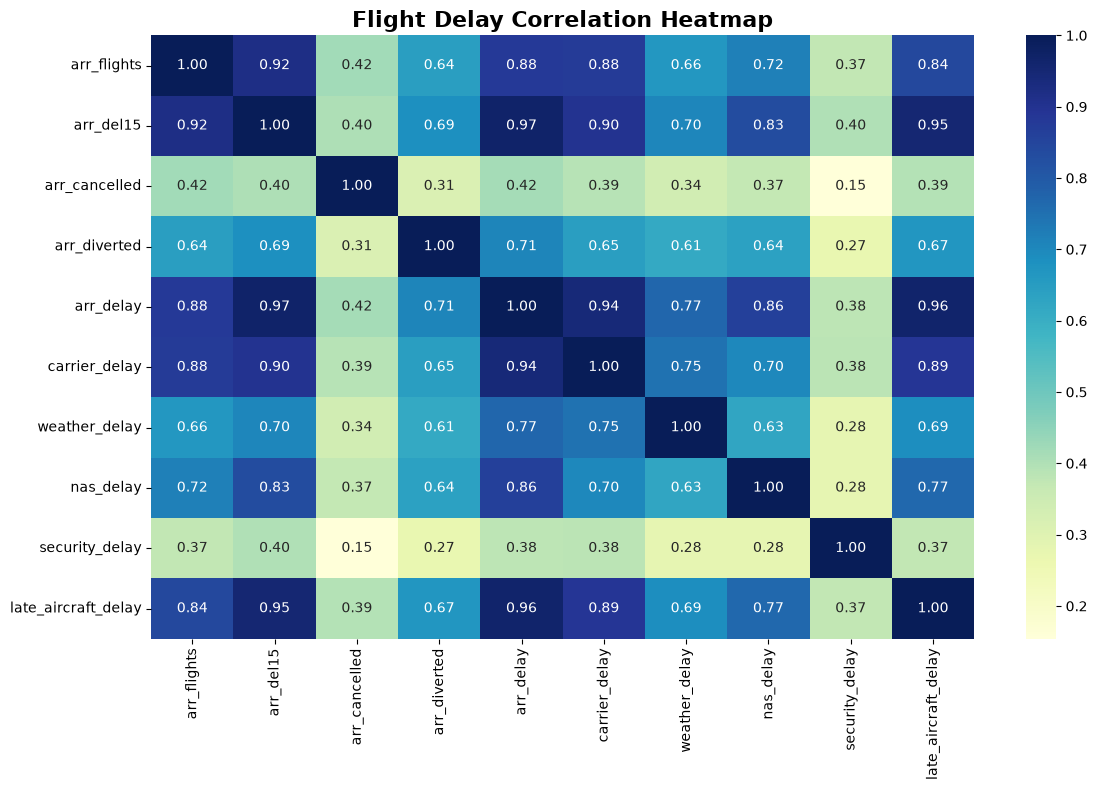

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = df_clean[
    [
        "arr_flights",
        "arr_del15",
        "arr_cancelled",
        "arr_diverted",
        "arr_delay",
        "carrier_delay",
        "weather_delay",
        "nas_delay",
        "security_delay",
        "late_aircraft_delay"
    ]
].corr()

plt.figure(figsize=(12, 8))

sns.heatmap(
    corr,
    annot=True,
    cmap="YlGnBu",
    fmt=".2f"
)

plt.title(
    "Flight Delay Correlation Heatmap",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

### 11. Distribution of Arrival Delays

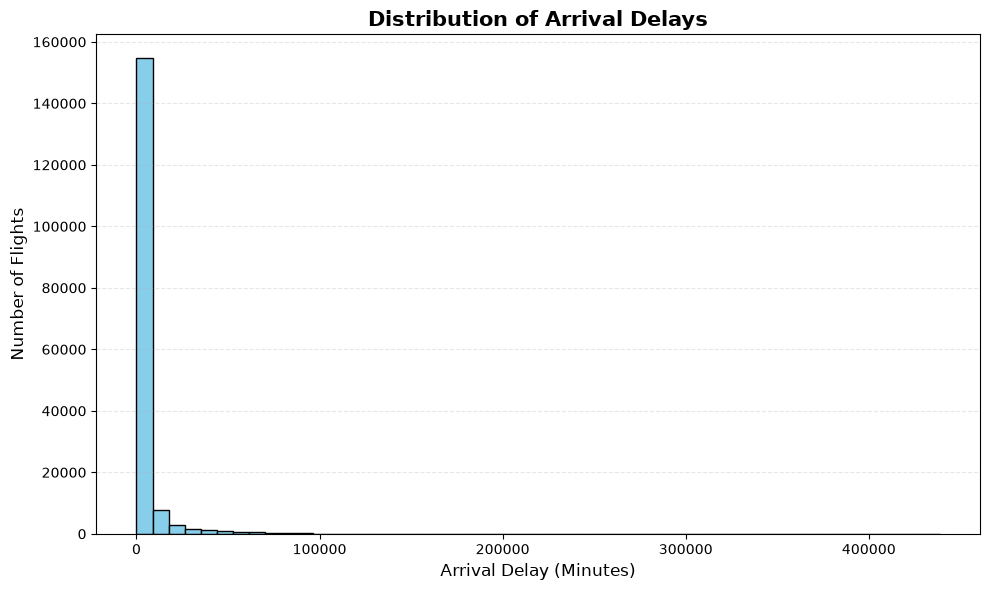

In [34]:
arrival_delay = df_clean["arr_delay"].dropna()

plt.figure(figsize=(10, 6))

plt.hist(
    arrival_delay,
    bins=50,
    color="skyblue",
    edgecolor="black"
)

plt.title(
    "Distribution of Arrival Delays",
    fontsize=15,
    fontweight="bold"
)

plt.xlabel(
    "Arrival Delay (Minutes)",
    fontsize=12
)

plt.ylabel(
    "Number of Flights",
    fontsize=12
)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.3
)

plt.tight_layout()
plt.show()

### 12. Top 10 Airlines by Average Arrival Delay
 

In [35]:
avg_airline_delay = (
    df_clean.groupby("carrier_name")["arr_delay"]
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

avg_airline_delay

carrier_name
Southwest Airlines Co.          11188.673778
American Airlines Inc.           8786.618935
United Air Lines Inc.            6255.616145
JetBlue Airways                  6095.361866
Spirit Air Lines                 4817.507358
Delta Air Lines Inc.             4742.181775
US Airways Inc.                  3809.885246
ExpressJet Airlines Inc.         3707.812834
American Eagle Airlines Inc.     3439.113985
SkyWest Airlines Inc.            3411.994318
Name: arr_delay, dtype: float64

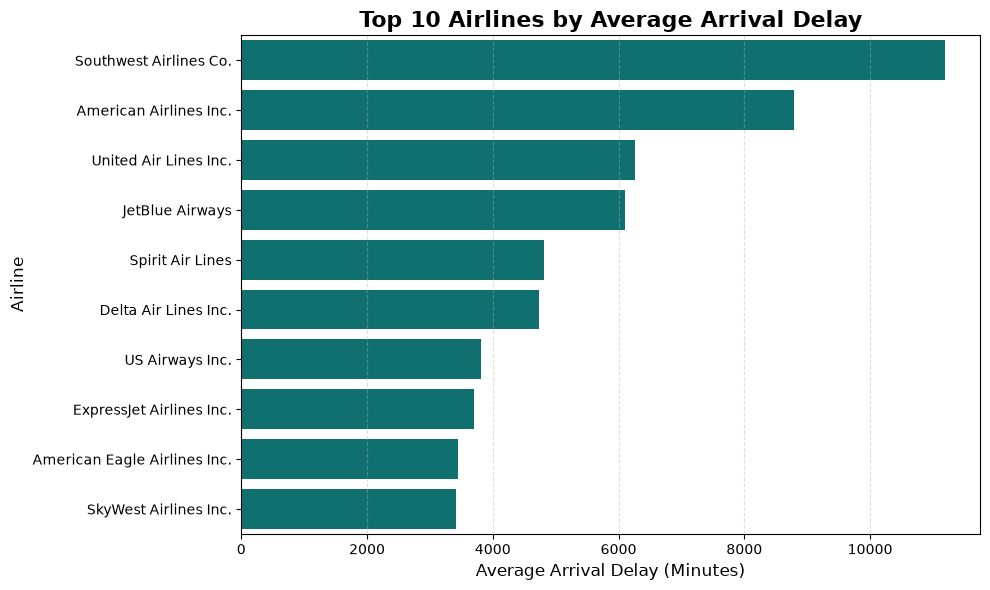

In [36]:
plt.figure(figsize=(10, 6))

sns.barplot(
    x=avg_airline_delay.values,
    y=avg_airline_delay.index,
    color="teal"
)

plt.title(
    "Top 10 Airlines by Average Arrival Delay",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Average Arrival Delay (Minutes)",
    fontsize=12
)

plt.ylabel(
    "Airline",
    fontsize=12
)

plt.grid(
    axis="x",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 13. Average Arrival Delay by Month

In [37]:
monthly_avg_delay = (
    df_clean.groupby("month")["arr_delay"]
    .mean()
)

monthly_avg_delay

month
1     4141.529858
2     3877.282893
3     3927.126430
4     3874.963664
5     4147.566861
6     5582.427243
7     5911.601044
8     5098.397868
9     3002.961101
10    3313.924826
11    3126.780969
12    4790.016046
Name: arr_delay, dtype: float64

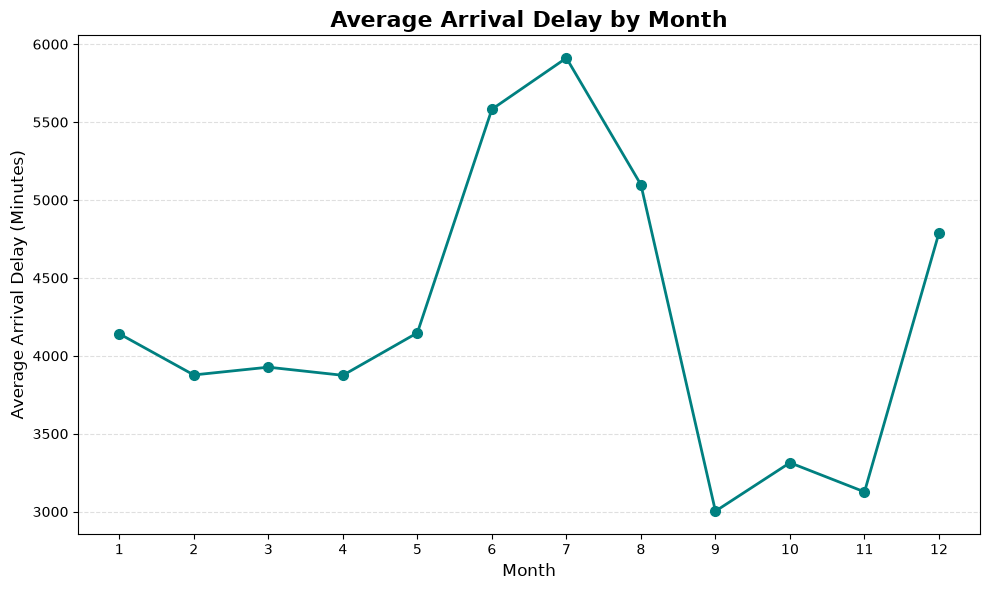

In [38]:
plt.figure(figsize=(10, 6))

plt.plot(
    monthly_avg_delay.index,
    monthly_avg_delay.values,
    marker="o",
    linewidth=2,
    markersize=7,
    color="teal"
)

plt.title(
    "Average Arrival Delay by Month",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel(
    "Month",
    fontsize=12
)

plt.ylabel(
    "Average Arrival Delay (Minutes)",
    fontsize=12
)

plt.xticks(range(1, 13))

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 14. Total Flights vs Delayed Flights

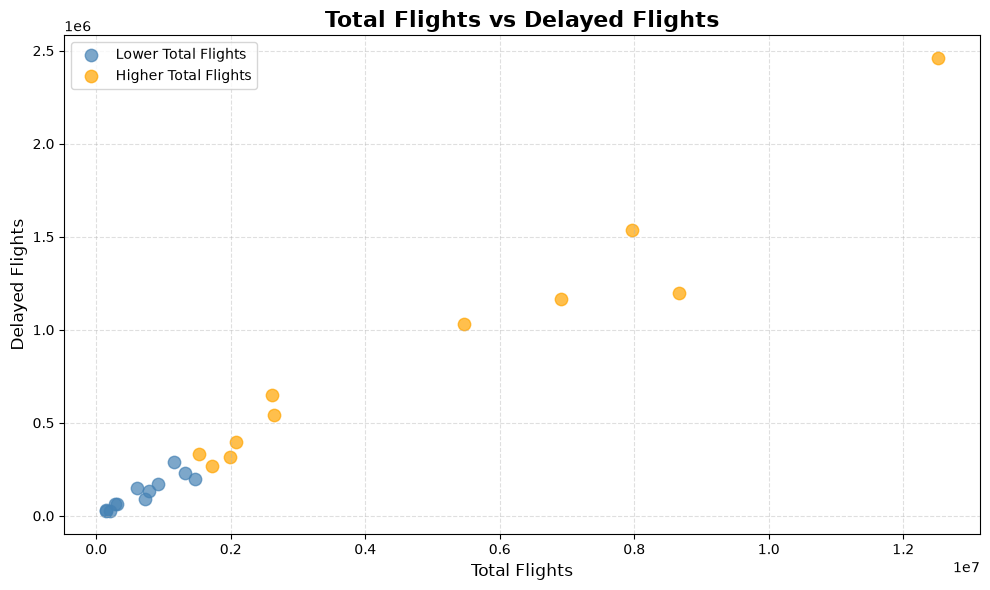

In [39]:
flight_comparison = (
    df_clean.groupby("carrier_name")
    .agg(
        total_flights=("arr_flights", "sum"),
        delayed_flights=("arr_del15", "sum")
    )
)

flight_comparison["flight_group"] = np.where(
    flight_comparison["total_flights"] <= flight_comparison["total_flights"].median(),
    "Lower Total Flights",
    "Higher Total Flights"
)

low = flight_comparison[
    flight_comparison["flight_group"] == "Lower Total Flights"
]

high = flight_comparison[
    flight_comparison["flight_group"] == "Higher Total Flights"
]

plt.figure(figsize=(10, 6))

plt.scatter(
    low["total_flights"],
    low["delayed_flights"],
    color="steelblue",
    alpha=0.7,
    s=80,
    label="Lower Total Flights"
)

plt.scatter(
    high["total_flights"],
    high["delayed_flights"],
    color="orange",
    alpha=0.7,
    s=80,
    label="Higher Total Flights"
)

plt.title(
    "Total Flights vs Delayed Flights",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Total Flights", fontsize=12)
plt.ylabel("Delayed Flights", fontsize=12)

plt.legend()

plt.grid(
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 15. Year wise Cancelled Flights

In [40]:
year_cancelled = (
    df_clean.groupby("year")["arr_cancelled"]
    .sum()
)

year_cancelled

year
2013     33041.0
2014    126983.0
2015     89882.0
2016     65859.0
2017     82689.0
2018    116538.0
2019    134918.0
2020    279063.0
2021    103055.0
2022    181269.0
2023     75616.0
Name: arr_cancelled, dtype: float64

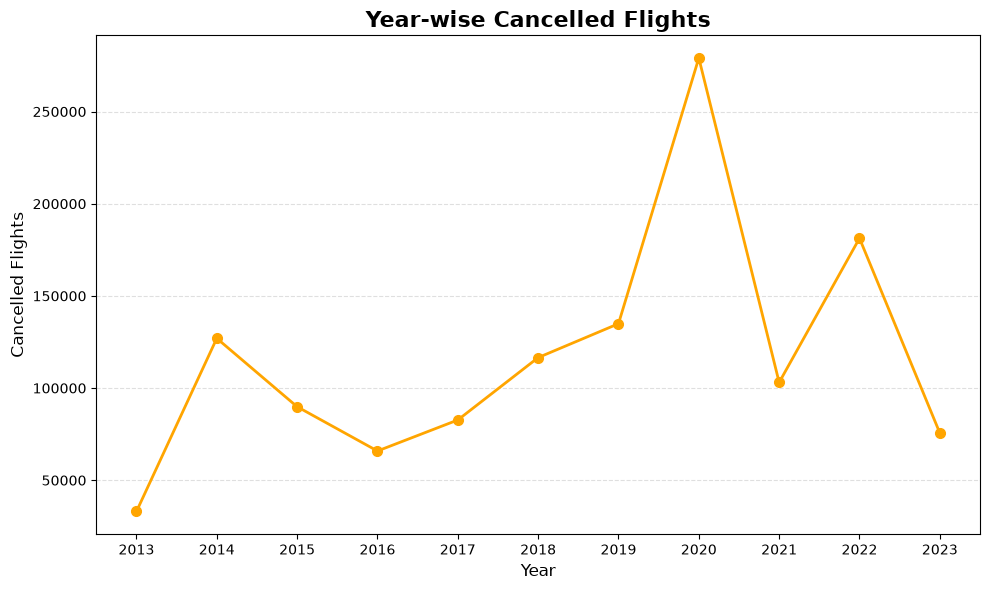

In [41]:
plt.figure(figsize=(10, 6))

plt.plot(
    year_cancelled.index,
    year_cancelled.values,
    marker="o",
    linewidth=2,
    markersize=7,
    color="orange"
)

plt.title(
    "Year-wise Cancelled Flights",
    fontsize=16,
    fontweight="bold"
)

plt.xlabel("Year", fontsize=12)
plt.ylabel("Cancelled Flights", fontsize=12)

plt.xticks(year_cancelled.index)

plt.grid(
    axis="y",
    linestyle="--",
    alpha=0.4
)

plt.tight_layout()
plt.show()

### 16. Year-wise Diverted Flights

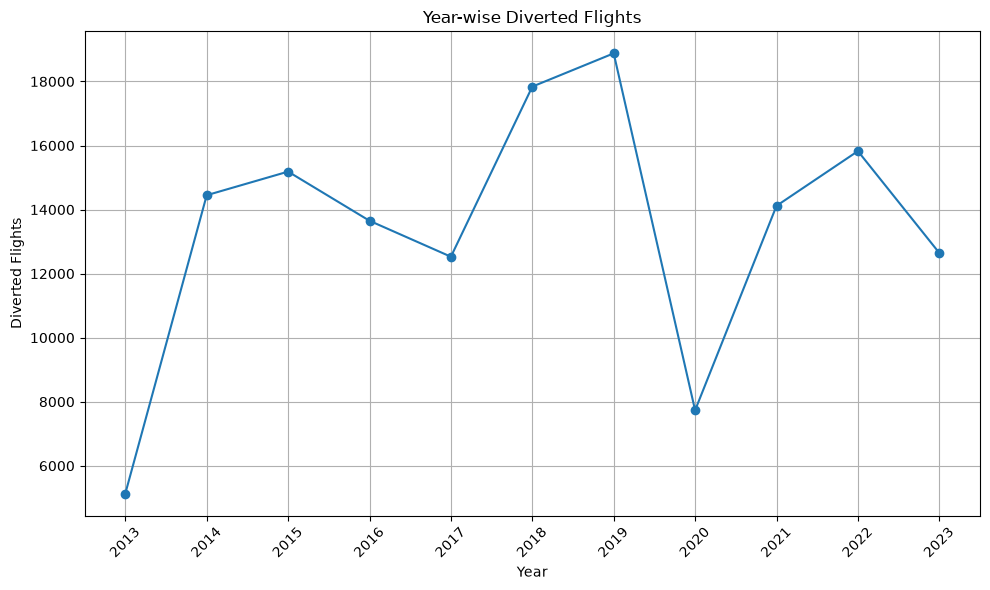

In [42]:
year_diverted = df_clean.groupby("year")["arr_diverted"].sum()

plt.figure(figsize=(10, 6))

plt.plot(
    year_diverted.index,
    year_diverted.values,
    marker="o"
)

plt.title("Year-wise Diverted Flights")
plt.xlabel("Year")
plt.ylabel("Diverted Flights")

plt.xticks(year_diverted.index, rotation=45)
plt.grid(True)

plt.tight_layout()
plt.show()

In [43]:
year_delay = (
    df_clean.groupby("year")["arr_del15"]
    .sum()
)

airline_delay = (
    df_clean.groupby("carrier_name")["arr_del15"]
    .sum()
)

print("Total Flights:", df_clean["arr_flights"].sum())

print("Total Delayed Flights:", df_clean["arr_del15"].sum())

print("Total Cancelled Flights:", df_clean["arr_cancelled"].sum())

print("Total Arrival Delay:", df_clean["arr_delay"].sum())

print("Highest Delay Month:", month_delay.idxmax())

print("Highest Delay Year:", year_delay.idxmax())

print("Top Delay Reason:", delay_reasons.idxmax())

print("Top Delayed Airport:", airport_delay.idxmax())

print("Top Delayed Airline:", airline_delay.idxmax())

Total Flights: 62144776.0
Total Delayed Flights: 11375095.0
Total Cancelled Flights: 1288913.0
Total Arrival Delay: 726758355.0
Highest Delay Month: 8
Highest Delay Year: 2019
Top Delay Reason: late_aircraft_delay
Top Delayed Airport: Chicago, IL: Chicago O'Hare International
Top Delayed Airline: Southwest Airlines Co.


In [44]:
import numpy as np

delay_values = df_clean["arr_delay"].values

print("Mean Arrival Delay:", np.mean(delay_values))
print("Median Arrival Delay:", np.median(delay_values))
print("Maximum Arrival Delay:", np.max(delay_values))
print("Minimum Arrival Delay:", np.min(delay_values))
print("Standard Deviation:", np.std(delay_values))

Mean Arrival Delay: 4244.513616745414
Median Arrival Delay: 1020.0
Maximum Arrival Delay: 438783.0
Minimum Arrival Delay: 0.0
Standard Deviation: 12625.162342453508


In [45]:
print("25th Percentile:", np.percentile(delay_values, 25))
print("50th Percentile:", np.percentile(delay_values, 50))
print("75th Percentile:", np.percentile(delay_values, 75))
print("90th Percentile:", np.percentile(delay_values, 90))
print("95th Percentile:", np.percentile(delay_values, 95))

25th Percentile: 336.0
50th Percentile: 1020.0
75th Percentile: 2888.5
90th Percentile: 8430.800000000017
95th Percentile: 18129.599999999977


## Key Insights

* **August** recorded the highest number of flight delays.
* **2019** had the highest yearly flight delays.
* **Late aircraft delays** were the major contributor to total delays.
* **Southwest Airlines** had the highest number of delayed flights.
* **Chicago O’Hare Airport** recorded the highest number of delayed flights.
* **Weather delays contributed to overall arrival delays and varied across different years.**
* Flight cancellations and diversions varied across different years.


## Conclusion

The Flight Delay Analysis project helped identify important patterns in flight delays, cancellations, and diversions. The analysis showed that delay frequency varies across airlines, airports, months, and delay reasons.

Overall, the project demonstrates how Python-based data analysis and visualization can be used to understand flight performance and identify factors contributing to delays.


## Future Scope

* Flight delay prediction can be performed using Machine Learning.
* Real-time flight data can be incorporated for live delay monitoring.
* Weather information can be combined with flight data for deeper analysis.
* An interactive dashboard can be developed using Power BI.
* Route-level analysis can be performed to identify frequently delayed routes.